In [2]:
import myQMLlib as myQML
import numpy as np
import matplotlib.pyplot as plt
import time

#Code to automatically reload the myQMLfunctions module when it is edited
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


-------- (Shots = 0, Realizations = 100) --------
Evaluating N_train = 10...
  -> QELM MSE: 0.0000
  -> K-LE MSE: 6.3137
  -> K-SW MSE: 6.3137
  -> Time:     33.6s
Evaluating N_train = 30...
  -> QELM MSE: 0.0000
  -> K-LE MSE: 0.0235
  -> K-SW MSE: 0.0235
  -> Time:     42.9s
Evaluating N_train = 50...
  -> QELM MSE: 0.0000
  -> K-LE MSE: 0.0316
  -> K-SW MSE: 0.0316
  -> Time:     33.3s
Evaluating N_train = 100...
  -> QELM MSE: 0.0000
  -> K-LE MSE: 0.0370
  -> K-SW MSE: 0.0370
  -> Time:     46.1s
Evaluating N_train = 200...
  -> QELM MSE: 0.0000
  -> K-LE MSE: 0.0393
  -> K-SW MSE: 0.0393
  -> Time:     72.5s
Evaluating N_train = 500...
  -> QELM MSE: 0.0000
  -> K-LE MSE: 0.0412
  -> K-SW MSE: 0.0412
  -> Time:     137.2s
Evaluating N_train = 1000...
  -> QELM MSE: 0.0000
  -> K-LE MSE: 0.0408
  -> K-SW MSE: 0.0408
  -> Time:     368.9s
Evaluating N_train = 2000...
  -> QELM MSE: 0.0000
  -> K-LE MSE: 0.0419
  -> K-SW MSE: 0.0419
  -> Time:     2280.1s
Experiment finished in 50.2

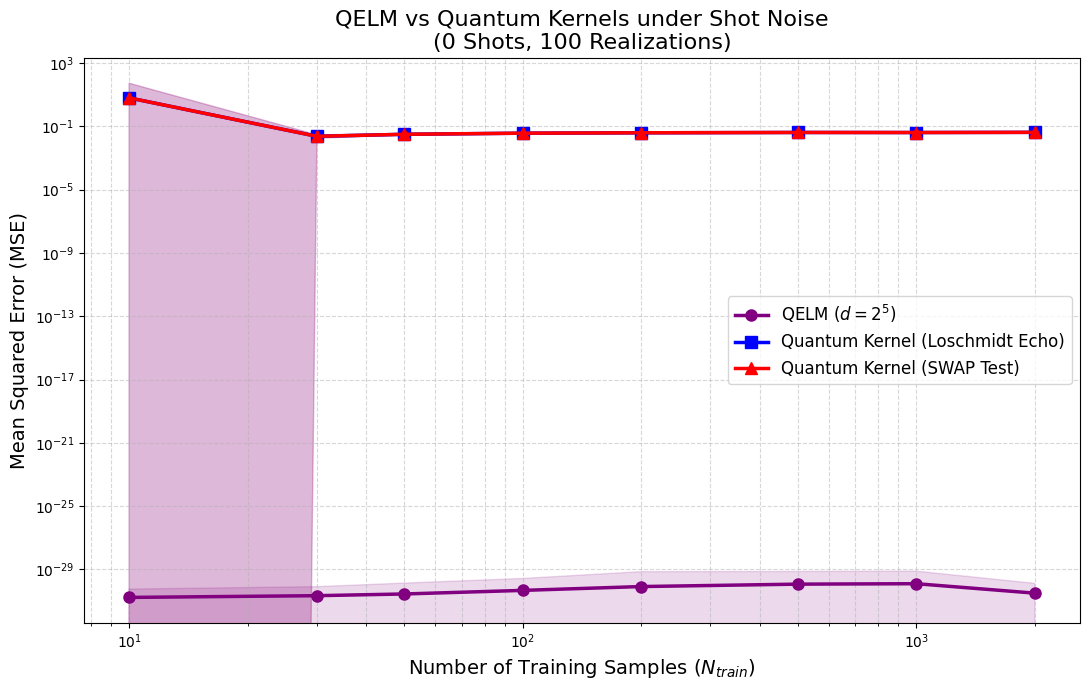

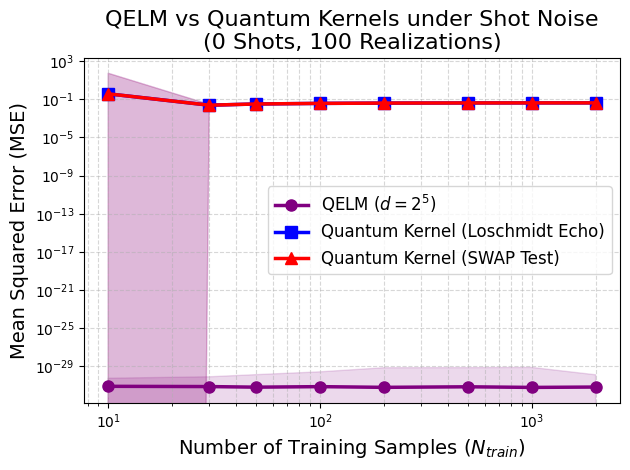

In [3]:
####### Settings #########
N_train_list = [10, 30, 50, 100, 200, 500, 1000, 2000]
N_test = 200
num_realizations = 100
num_shots = 0

reg_lambda = 0

#QELM reservoir physical setup
d_in = 2
d_res = 64
d_out = d_in * d_res
povm = myQML.generate_computational_povm(d_res)  # Using computational basis POVM for a more deterministic feature map
num_povm_elements = len(povm)


# Storage dictionaries
results = {'QELM': [], 'Kernel_LE': [], 'Kernel_SWAP': []}
results_median = {'QELM': [], 'Kernel_LE': [], 'Kernel_SWAP': []}
stds = {'QELM': [], 'Kernel_LE': [], 'Kernel_SWAP': []}

print(f"-------- (Shots = {num_shots}, Realizations = {num_realizations}) --------")
print("="*70)

total_time = time.time()

for N_train in N_train_list:
    print(f"Evaluating N_train = {N_train}...")
    mse_runs = {'QELM': [], 'Kernel_LE': [], 'Kernel_SWAP': []}
    step_time = time.time()

    for r in range(num_realizations):
        ds = myQML.QuantumDatasetGenerator(N_train, N_test, myQML.X)
        ds.generate_density_matrices()
        ds.compute_expectation_values()
        rho_train, y_train = ds.get_training_dataset()
        rho_test, y_test = ds.get_test_dataset()

        # QELM
        V = myQML.random_isometry(d_in, d_in * d_res)
        qelm = myQML.QuantumExtremeLearningMachine(
            isometry=V, 
            povm=povm, 
            bipartite_dims=(d_in, d_res), 
            keep_subsystem=1, 
            num_shots=num_shots
        )
        qelm.fit(rho_train, y_train)
        mse_runs['QELM'].append(np.mean((qelm.predict(rho_test) - y_test)**2))
        
        # Kernel LE
        kernel_le = myQML.QuantumKernelRegression(reg_lambda, num_shots)
        kernel_le.fit(rho_train, y_train, "le")
        mse_runs['Kernel_LE'].append(np.mean((kernel_le.predict(rho_test) - y_test)**2))

        # Kernel SWAP
        kernel_swap = myQML.QuantumKernelRegression(reg_lambda, num_shots)
        kernel_swap.fit(rho_train, y_train, "swap")
        mse_runs['Kernel_SWAP'].append(np.mean((kernel_swap.predict(rho_test) - y_test)**2))

    # Store results
    for key in results.keys():
        results[key].append(np.mean(mse_runs[key]))
        results_median[key].append(np.median(mse_runs[key]))
        stds[key].append(np.std(mse_runs[key]))

    print(f"  -> QELM MSE: {results['QELM'][-1]:.4f}")
    print(f"  -> K-LE MSE: {results['Kernel_LE'][-1]:.4f}")
    print(f"  -> K-SW MSE: {results['Kernel_SWAP'][-1]:.4f}")
    print(f"  -> Time:     {time.time() - step_time:.1f}s")

print("="*70)
print(f"Experiment finished in {(time.time() - total_time)/60:.1f} minutes.")

# Plot
plt.figure(figsize=(11, 7))
N_arr = np.array(N_train_list)

colors = {'QELM': 'purple', 'Kernel_LE': 'blue', 'Kernel_SWAP': 'red'}
labels = {'QELM': 'QELM ($d=2^5$)', 
          'Kernel_LE': 'Quantum Kernel (Loschmidt Echo)', 
          'Kernel_SWAP': 'Quantum Kernel (SWAP Test)'}
markers = {'QELM': 'o', 'Kernel_LE': 's', 'Kernel_SWAP': '^'}

for model in results.keys():
    mean_arr = np.array(results[model])
    median_arr = np.array(results_median[model])
    std_arr = np.array(stds[model])
    
    plt.plot(N_arr, mean_arr, label=labels[model], color=colors[model], 
             marker=markers[model], linewidth=2.5, markersize=8)
    plt.fill_between(N_arr, mean_arr - std_arr, mean_arr + std_arr, 
                     color=colors[model], alpha=0.15)

plt.xscale('log')
plt.yscale('log')
plt.xlabel('Number of Training Samples ($N_{train}$)', fontsize=14)
plt.ylabel('Mean Squared Error (MSE)', fontsize=14)
plt.title(f'QELM vs Quantum Kernels under Shot Noise\n({num_shots} Shots, {num_realizations} Realizations)', fontsize=16)
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.legend(fontsize=12)
plt.tight_layout()
plt.show()

for model in results.keys():
    mean_arr = np.array(results[model])
    median_arr = np.array(results_median[model])
    std_arr = np.array(stds[model])
    
    plt.plot(N_arr, median_arr, label=labels[model], color=colors[model], 
             marker=markers[model], linewidth=2.5, markersize=8)
    plt.fill_between(N_arr, mean_arr - std_arr, mean_arr + std_arr, 
                     color=colors[model], alpha=0.15)

plt.xscale('log')
plt.yscale('log')
plt.xlabel('Number of Training Samples ($N_{train}$)', fontsize=14)
plt.ylabel('Mean Squared Error (MSE)', fontsize=14)
plt.title(f'QELM vs Quantum Kernels under Shot Noise\n({num_shots} Shots, {num_realizations} Realizations)', fontsize=16)
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.legend(fontsize=12)
plt.tight_layout()
plt.show()